In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

In [12]:
import yfinance as yf

def get_valuation_metrics(ticker_symbol, company_name):
    stock = yf.Ticker(ticker_symbol)
    info = stock.info

    #pulling data from yf
    pe = info.get('trailingPE', None)
    mktcap = info.get('marketCap', None)

    #formatting for display
    mktcap_display = f"${mktcap/1e12:,.2f}T" if mktcap is not None else "N/A"
    pe_display = round(pe, 2) if pe else "N/A"

    return {
        'company': company_name,
        'ticker': ticker_symbol,
        'pe': pe_display,
        'market_cap': mktcap_display
    }

# define tickers
tickers = {
    'NVDA': 'NVIDIA',
    'TSM': 'TSMC',
    'ASML': 'ASML'
}

# pulling all metrics
results = [get_valuation_metrics(t, n) for t, n in tickers.items()]

# display table
print("=" * 45)
print(f"{'Company':<10} | {'P/E':>8} | {'Mkt Cap':>10}")
print("=" * 45)
for r in results:
    print(f"{r['company']:<10} | {str(r['pe']):>8} | {r['market_cap']:>10}")

# cisco benchmark, manually assigned
# verified historical figure from Jadagoudar (2024), SSRN 4786491
cisco_peak_pe = 200
cisco_peak_mktcap = "~$500B"

print("=" * 45)
print(f"{'Cisco':<10} | {str(cisco_peak_pe):>8} | {cisco_peak_mktcap:>10}  (2000 peak)")
print("=" * 45)
print("\nData sources:")
print("Live data: Yahoo Finance via yfinance")
print("Cisco 2000 peak: Jadagoudar (2024), SSRN 4786491")

Company    |      P/E |    Mkt Cap
NVIDIA     |    35.24 |     $4.20T
TSMC       |    31.84 |     $1.71T
ASML       |    46.51 |     $0.52T
Cisco      |      200 |     ~$500B  (2000 peak)

Data sources:
Live data: Yahoo Finance via yfinance
Cisco 2000 peak: Jadagoudar (2024), SSRN 4786491


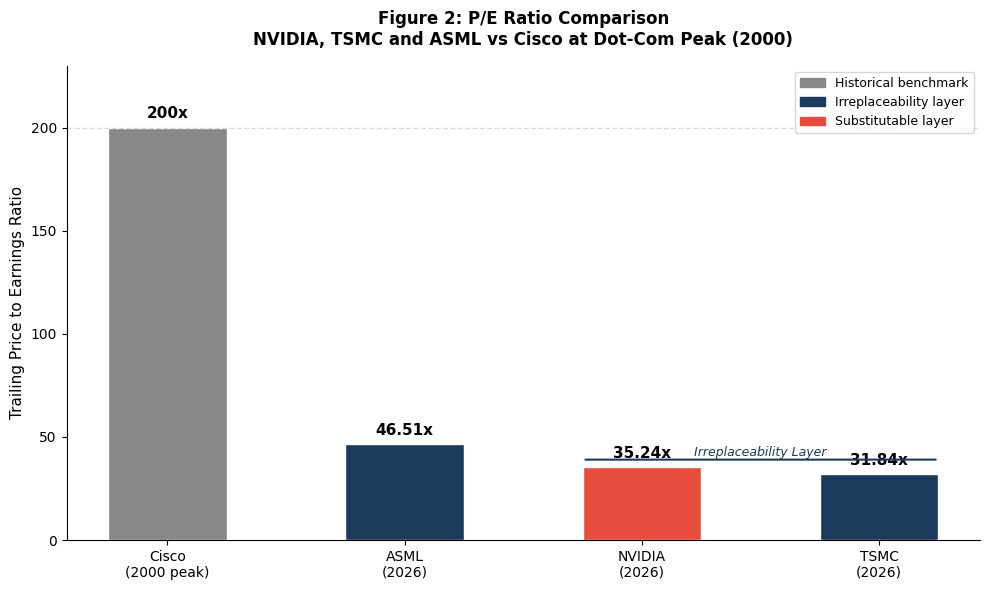

Figure 2 saved


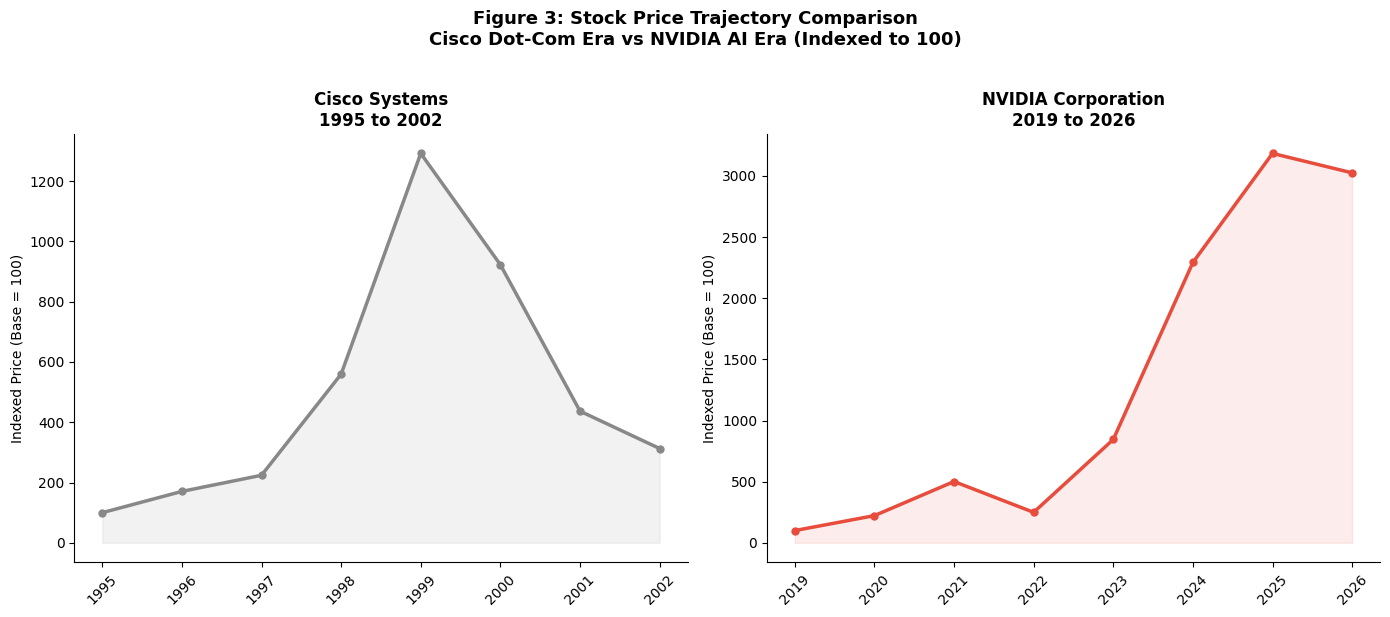

Figure 3 saved


In [14]:
# ── FIGURE 2: P/E RATIO COMPARISON BAR CHART ──────────────────────────────

# using verified live data from valuation table above
pe_data = {
    'Cisco\n(2000 peak)': 200,
    'ASML\n(2026)': 46.51,
    'NVIDIA\n(2026)': 35.24,
    'TSMC\n(2026)': 31.84
}

companies = list(pe_data.keys())
pe_ratios = list(pe_data.values())

# grey for cisco, navy for irreplaceability layer, red for nvidia
colors = ['#888888', '#1B3A5C', '#E74C3C', '#1B3A5C']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(companies, pe_ratios, color=colors, width=0.5, edgecolor='white')

# value labels on top of each bar
for bar, val in zip(bars, pe_ratios):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{val}x',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# reference line at cisco peak
ax.axhline(y=200, color='#888888', linestyle='--', alpha=0.3, linewidth=1)

# bracket label for irreplaceability layer
ax.annotate('',
            xy=(3.25, 39), xytext=(1.75, 39),
            arrowprops=dict(arrowstyle='-', color='#1B3A5C', lw=1.5))
ax.text(2.5, 41, 'Irreplaceability Layer', ha='center',
        fontsize=9, color='#1B3A5C', style='italic')

ax.set_ylabel('Trailing Price to Earnings Ratio', fontsize=11)
ax.set_title('Figure 2: P/E Ratio Comparison\nNVIDIA, TSMC and ASML vs Cisco at Dot-Com Peak (2000)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_ylim(0, 230)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend
grey_patch = mpatches.Patch(color='#888888', label='Historical benchmark')
navy_patch = mpatches.Patch(color='#1B3A5C', label='Irreplaceability layer')
red_patch = mpatches.Patch(color='#E74C3C', label='Substitutable layer')
ax.legend(handles=[grey_patch, navy_patch, red_patch],
          loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figure2_pe_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 saved")


# ── FIGURE 3: STOCK PRICE TRAJECTORY COMPARISON ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# downloading historical price data
cisco = yf.download('CSCO', start='1995-01-01', end='2002-12-31',
                    auto_adjust=True, progress=False)
nvda = yf.download('NVDA', start='2019-01-01', end='2026-03-01',
                   auto_adjust=True, progress=False)

# resample to annual end of year prices
cisco_annual = cisco['Close'].resample('YE').last().squeeze()
nvda_annual = nvda['Close'].resample('YE').last().squeeze()

# normalize both to 100 at start for fair comparison
cisco_norm = (cisco_annual / cisco_annual.iloc[0] * 100)
nvda_norm = (nvda_annual / nvda_annual.iloc[0] * 100)

# cisco chart
axes[0].plot(range(len(cisco_norm)), cisco_norm.values,
             color='#888888', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(range(len(cisco_norm)), cisco_norm.values,
                     alpha=0.1, color='#888888')
axes[0].set_title('Cisco Systems\n1995 to 2002',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Indexed Price (Base = 100)', fontsize=10)
axes[0].set_xticks(range(len(cisco_norm)))
axes[0].set_xticklabels([str(d.year) for d in cisco_norm.index], rotation=45)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# nvidia chart
axes[1].plot(range(len(nvda_norm)), nvda_norm.values,
             color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(range(len(nvda_norm)), nvda_norm.values,
                     alpha=0.1, color='#E74C3C')
axes[1].set_title('NVIDIA Corporation\n2019 to 2026',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Indexed Price (Base = 100)', fontsize=10)
axes[1].set_xticks(range(len(nvda_norm)))
axes[1].set_xticklabels([str(d.year) for d in nvda_norm.index], rotation=45)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 3: Stock Price Trajectory Comparison\nCisco Dot-Com Era vs NVIDIA AI Era (Indexed to 100)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('figure3_trajectory_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved")